# ScaleRAG Evaluation and Scaling Analysis

We evaluate the ScaleRAG, a hierarchical retrieval-augmented generation system, on a sampled arXiv QA. It runs adaptive multi-level retrieval (paper → section → chunk), logs fine-grained timing for embedding, per-level retrieval, generation, and end-to-end latency, and analyzes how these components behave across the full distribution and tail (P95/P99). The notebook also looks at how retrieval depth affects latency, inspects qualitative examples from the fastest and slowest queries, and includes a small LLM-based evaluation to sanity-check retrieval relevance and answer quality. The goal is to understand efficiency trade-offs and verify that hierarchical retrieval adds minimal overhead compared to generation.

In [61]:
import os
import sys
import transformers
from pathlib import Path
import ujson as json
import json
import pandas as pd
from datetime import datetime
import random
from openai import OpenAI
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt

In [62]:
load_dotenv("keys.env")
client = OpenAI()
MODEL = "gpt-5-nano"

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_USE_LEGACY_CACHE"] = "1"

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [3]:
from rag_core_scale import ScaleRAGPipeline

rag = ScaleRAGPipeline(
    index_l1_path="data/faiss/l1_global.faiss",
    emb_l1_path="data/embeddings/emb_l1_1000.npy",
    meta_l1_path="data/metadata/meta_l1_1000.json",
    meta_l2_path="data/metadata/meta_l2_1000.json",
    meta_l3_path="data/metadata/meta_l3_1000.json",
    l2_manifest_path="data/metadata/l2_manifest.json",
    l3_manifest_path="data/metadata/l3_manifest.json",
)

`torch_dtype` is deprecated! Use `dtype` instead!
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:37<00:00, 18.91s/it]


In [4]:
# load the QA dataset

DATASET_NAME = "arxiv_scale_rag_self_instruct_v1"

DATASET_PATH = Path("data/QnA/eval_qas_self_instruct.jsonl")
with DATASET_PATH.open("r", encoding="utf-8") as f:
    qna_dataset = [json.loads(line) for line in f]

## 1) RAG Evaluation Loop

This function runs an end-to-end evaluation of the RAG pipeline over a question–answer dataset. For each query, it executes retrieval and generation using the configured RAG system, records the model’s answer along with the retrieved contexts, and logs fine-grained latency measurements (embedding, retrieval, generation, and total time). The output is a structured run log containing query metadata, gold answers, model responses, and performance timings, which can be saved as JSONL for downstream analysis of quality, latency, and scalability trade-offs.

In [5]:
def run_rag_eval(qna_dataset):
    run_log = []
    total = len(qna_dataset)

    for i, ex in enumerate(qna_dataset):
        q = ex["question"]
        gold = ex.get("answer")
        qid = ex.get("id")

        # 🔹 Adaptive RAG call (no k)
        out = rag.run(q)

        run_log.append({
            "query_id": qid,
            "dataset": DATASET_NAME,

            "query": q,
            "gold_answer": gold,
            "answer": out["answer"],

            "contexts": out["contexts"],
            "timing": out["timing"],

            "rag_config": out["config"],
            "timestamp": datetime.utcnow().isoformat(),
        })

        if i % 10 == 0:
            print(f"Processed {i}/{total} queries...")

    return run_log

In [6]:
random.seed(42)  
qna_dataset_small = random.sample(qna_dataset, 100)
run_log = run_rag_eval(qna_dataset_small)

You are not running the flash-attention implementation, expect numerical differences.


Processed 0/100 queries...
Processed 10/100 queries...
Processed 20/100 queries...
Processed 30/100 queries...
Processed 40/100 queries...
Processed 50/100 queries...
Processed 60/100 queries...
Processed 70/100 queries...
Processed 80/100 queries...
Processed 90/100 queries...


In [11]:
def save_log(run_log, path: Path):
    with path.open("w", encoding="utf-8") as f:
        for row in run_log:
            f.write(json.dumps(row) + "\n")

In [12]:
for row in run_log:
    row.pop("config", None)

save_dir = Path("data") / "QnA"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "log_scaleRAG_1000PDF_improved2.jsonl"
save_log(run_log, save_path)

In [37]:
save_path = Path("data/QnA/log_scaleRAG_1000PDF_improved2.jsonl")

rows = []
with open(save_path, "r") as f:
    for line in f:
        r = json.loads(line)
        timing = r.pop("timing", {})
        r.update(timing)   
        rows.append(r)

df = pd.DataFrame(rows)

## 2) Latency Results for Embedding, Retrieval & Generation

In [38]:
df = df.assign(
    embedding_ms=df["embed_query_ms"],
    l1_search_ms=df.get("l1_search_ms", 0.0),
    l2_search_ms=df.get("l2_search_ms", 0.0),
    l3_search_ms=df.get("l3_search_ms", 0.0),
    retrieval_ms=df.get("retrieval_ms", 0.0),
    generation_ms=df.get("generation_ms", 0.0),
)

In [16]:
def plot_latency(lat, title_prefix, outname):
    p95, p99 = np.percentile(lat, [95, 99])

    subsets = [
        (lat, "Full"),
        (lat[lat <= p99], "P99"),
        (lat[lat <= p95], "P95"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(6, 7))

    for ax, (data, label) in zip(axes, subsets):
        ax.hist(data, bins=40 if label != "Full" else 50)
        ax.set_title(f"{title_prefix} ({label})")
        ax.set_xlabel("ms")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(outname, dpi=300, bbox_inches="tight")
    plt.show()


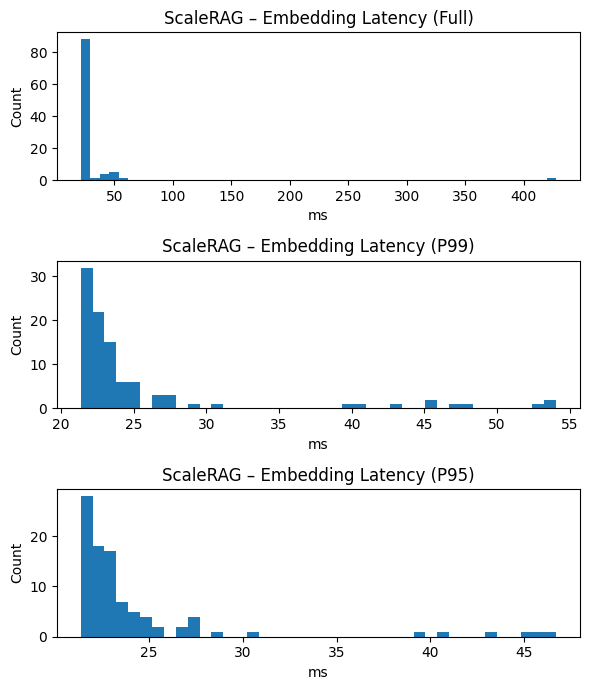

In [22]:
plot_latency(
    df["embedding_ms"].values,
    "ScaleRAG – Embedding Latency",
    "ScaleRAG_embedding_latency.png"
)

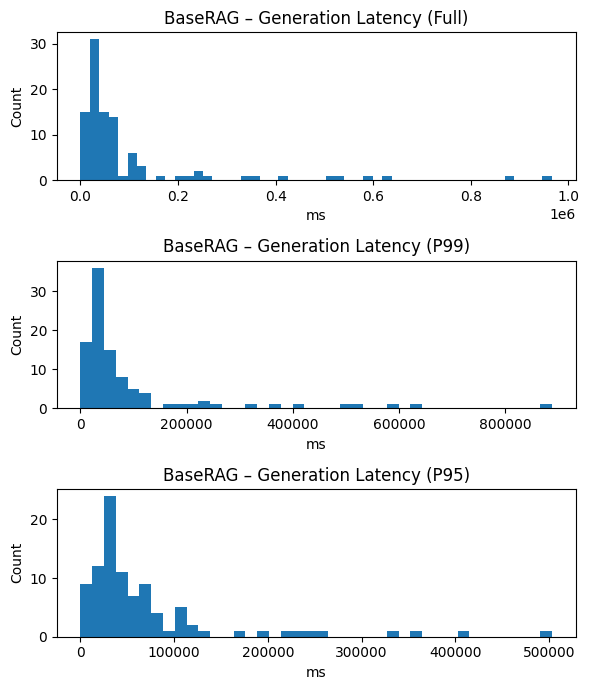

In [23]:
plot_latency(
    df["generation_ms"].values,
    "BaseRAG – Generation Latency",
    "BaseRAG1_generation_latency.png"
)

## 3) Latency based on Retrieval Depth

In [24]:
df["retrieval_level"] = df["contexts"].apply(lambda x: x["level"])
df["retrieval_level"].value_counts().sort_index()

retrieval_level
1     3
2    69
3    28
Name: count, dtype: int64

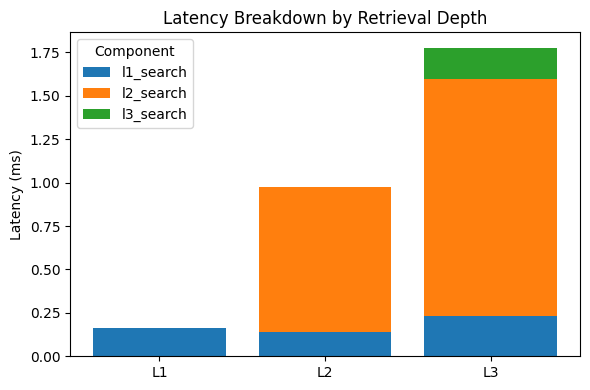

In [26]:
components = ["l1_search_ms",
              "l2_search_ms",
              "l3_search_ms",]

grouped = (df.groupby("retrieval_level")[components]
             .mean()
             .sort_index())


fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(grouped))
bottom = np.zeros(len(grouped))

for comp in components:
    ax.bar(x,
           grouped[comp],
           bottom=bottom,
           label=comp.replace("_ms", ""))
    bottom += grouped[comp].values

ax.set_xticks(x)
ax.set_xticklabels([f"L{lvl}" for lvl in grouped.index])
ax.set_ylabel("Latency (ms)")
ax.set_title("Latency Breakdown by Retrieval Depth")
ax.legend(title="Component")

plt.tight_layout()
plt.savefig("BaseRAG1_latencyBreakdown.png", dpi=300, bbox_inches="tight")
plt.show()


## 4) Qualitative Results

In [63]:
LOG_PATH = Path("data/QnA/log_scaleRAG_1000PDF_improved2.jsonl")  

rows = []
with open(LOG_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

rows = rows[:10]  

In [66]:
def get_eval_units(contexts):

    if isinstance(contexts, dict):
        
        if contexts.get("chunks"):
            return contexts["chunks"][:5]      # generator uses chunks
            
        if contexts.get("sections"):
            return contexts["sections"][:5]    # match build_context
            
        return contexts.get("papers", [])[:5]
 
    units = list(reversed(contexts))
    return units[:5]


In [67]:
def extract_text(u):
    
    if u.get("text_for_embedding"):
        return u["text_for_embedding"]
        
    if u.get("text"):
        return u["text"]
        
    if u.get("image_summary"):
        return u["image_summary"]
        
    return ""

In [68]:
def hit_at_k(rels, k):
    return int(any(r > 0 for r in rels[:k]))


def recall_at_k(rels, k):
    total_relevant = sum(r > 0 for r in rels)
    if total_relevant == 0:
        return 0.0
    return sum(r > 0 for r in rels[:k]) / total_relevant


def dcg_at_k(rels, k):
    return sum(
        rels[i] / np.log2(i + 2)
        for i in range(min(k, len(rels)))
    )

In [82]:
def judge_query(query, gold_answer, pred_answer, contexts, model=MODEL):
    """
    contexts: list of retrieved chunks
              index 0 = lowest similarity
              index -1 = highest similarity
    """

    # contexts is a LIST → reverse to rank best → worst
    chunks = list(reversed(contexts))

    chunk_text = "\n\n".join(
        [
            f"[Chunk {i+1}]\n{c.get('text_for_embedding', '')}"
            for i, c in enumerate(chunks)
        ]
    )

    prompt = f"""
You are evaluating a Retrieval-Augmented Generation (RAG) system.

QUESTION:
{query}

GOLD ANSWER:
{gold_answer}

MODEL ANSWER:
{pred_answer}

RETRIEVED CHUNKS (ranked best to worst):
{chunk_text}

TASKS:
1. For each chunk, assign a relevance score:
   - 2 = directly supports the gold answer
   - 1 = partially relevant
   - 0 = irrelevant

2. Score the MODEL ANSWER from 0 to 1 based on correctness vs GOLD ANSWER.

Return JSON ONLY in this format:
{{
  "chunk_relevance": [r1, r2, r3, r4, r5],
  "answer_score": float
}}
"""

    resp = client.responses.create(
        model=model,
        input=prompt,
    )

    return json.loads(resp.output_text)


In [83]:
eval_units = get_eval_units(row["contexts"])
K = 5
results = []

for row in rows:

    eval_units = get_eval_units(row["contexts"])

    out = judge_query(
        row["query"],
        row["gold_answer"],
        row["answer"],
        eval_units,
    )

    rels = out["chunk_relevance"]

    results.append({
        "hit@5": hit_at_k(rels, K),
        "recall@5": recall_at_k(rels, K),
        "dcg@5": dcg_at_k(rels, K),
        "answer_score": out["answer_score"],
    })

In [84]:
df2 = pd.DataFrame(results)

summary = df2.mean().to_frame(name="ScaleRAG (N=10)")
summary

,ScaleRAG (N=10)
hit@5,1.000000
recall@5,1.000000
dcg@5,2.948459
answer_score,0.540000


# Auxiliary Results

In [52]:
top = df.nsmallest(3, "retrieval_ms")

for _, r in top.iterrows():
    print("=" * 80)
    print(f"retrieval_ms: {r.retrieval_ms:.2f}\n")
    print(f"(Q): {r.query}")
    print(f"(A): {r.answer}")
    print(f"(Golden Truth): {r.gold_answer}")


retrieval_ms: 22.38

(Q): What receptive-field size was fixed for the CNN in the GoL training?
(A): The receptive-field size was not explicitly mentioned in the provided context. Therefore, the answer is Not found.
(Golden Truth): 3x3 cells.
retrieval_ms: 22.39

(Q): How are the latent vectors z*1 and z*2 obtained?
(A): The latent vectors z*1 and Z*2 are obtained through an optimization process that maximizes the log-likelihood function, which involves computing gradients with respect to the latent variables. The gradient computation uses the Jacobian matrix of the transformation UBa(τi) with respect to B, denoted as J, and the difference in average pixel intensities between object and background regions, denoted as ∆. The optimization process likely involves iterative algorithms such as gradient ascent or variants thereof, adjusting the latent vectors to increase the likelihood of the observed data under the model. The exact method for obtaining these vectors is not explicitly describ

In [53]:
top = df.nlargest(3, "retrieval_ms")

for _, r in top.iterrows():
    print("=" * 80)
    print(f"retrieval_ms: {r.retrieval_ms:.2f}\n")
    print(f"(Q): {r.query}")
    print(f"(A): {r.answer}")
    print(f"(Golden Truth): {r.gold_answer}")


retrieval_ms: 445.33

(Q): How is the G-rule defined relative to the F-rule, and what does this ensure about growth?
(A): The G-rule is defined relative to the F-rule through a recursive relationship that bounds the sum of the products of the growth rate (G) and the time intervals (τ), ensuring that the growth is controlled and does not exceed a certain limit. This is achieved by using a bound that involves the logarithm of the sum of the growth rates and their corresponding time intervals, multiplied by constants that depend on the system's parameters.

Answer: Recursive bound involving logarithmic sum of growth rates and time intervals.
(Golden Truth): The G-rule is defined deterministically given the F-rule, so that all line segments ('F' and 'G') grow at the same rate at each iteration.
retrieval_ms: 55.24

(Q): What is the target of the further research and experimentation?
(A): The target of further research and experimentation is the optimal s -t cut in the context of Horde's sc